In [1]:
# Imports des modules nécessaires 
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Extention du chemin
sys.path.append('../src')
sys.path.append('../data')

# Imports des fonctions définies
from Load_Data import load_parquet, construct_dataframe
from Plot_Functions import plot_timeseries, compute_market_price_by_country,estimate_electricity_price
from cost_dict import cost_dict  # doit être un fichier cost_dict.py
from data_generator import generate_fake_energy_data

### Création d'une fonction de génération de donnée, n'ayant pas accés à l'ancienne base de donnée

In [2]:
df = generate_fake_energy_data(start='2023-06-01', periods=48, freq='H')
#df.head()

c:\Users\quent\Librairy\EnerData_Project\notebook\../data\data_generator.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=start, periods=periods, freq=freq)


### Création de fonction de visualisation

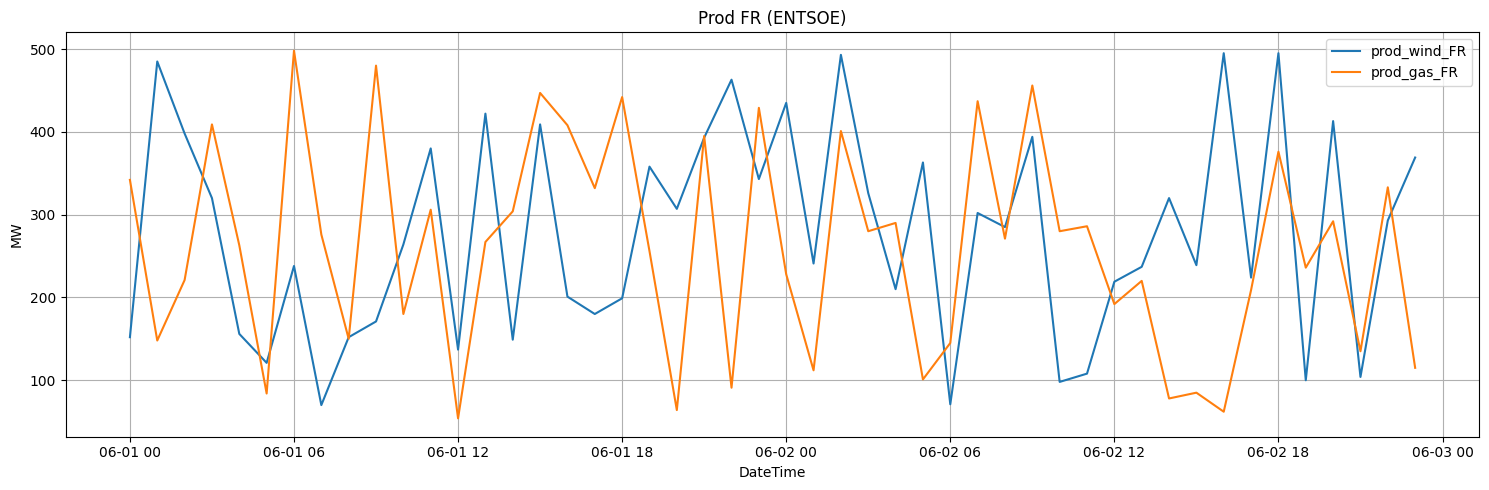

In [3]:
plot_timeseries(df, variables=['prod_wind_FR', 'prod_gas_FR'], title='Prod FR', ylabel='MW')


### Réalisation d'une fonction de dé-stockage standardisé, afin de pouvoir appliquer les différentes fonctions et estimation sur des données normées  

In [4]:
df_fr = construct_dataframe(df, countries=['FR'], production_name=['wind', 'gas', 'solar', 'coal', 'nuclear'])
df_fr.head()

c:\Users\quent\Librairy\EnerData_Project\notebook\../src\Load_Data.py:38: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_index = pd.date_range(start=time_range[0], end=time_range[1], freq=freq)


,DateTime,prod_wind_FR,prod_gas_FR,prod_solar_FR,prod_coal_FR,prod_nuclear_FR,link_FR_DE,link_FR_IT,link_FR_ES,link_DE_FR,link_IT_FR,link_ES_FR,Demand_FR,Price_FR
0,2023-06-01 00:00:00,152.0,342.0,180.0,219.0,301.0,-18.0,36.0,15.0,41.0,40.0,26.0,1132.0,171.425157
1,2023-06-01 01:00:00,485.0,148.0,356.0,94.0,239.0,-3.0,-18.0,-19.0,30.0,-17.0,30.0,1351.0,102.299898
2,2023-06-01 02:00:00,398.0,221.0,184.0,111.0,345.0,25.0,16.0,36.0,18.0,40.0,-11.0,1289.0,64.426483
3,2023-06-01 03:00:00,320.0,409.0,70.0,490.0,262.0,8.0,-33.0,12.0,44.0,-34.0,-6.0,1563.0,191.078490
4,2023-06-01 04:00:00,156.0,263.0,378.0,183.0,257.0,35.0,-26.0,35.0,-46.0,-8.0,45.0,1237.0,109.635803


### Création d'une fonction coût, calculant grâce au marché SPOT, le prix estimé de l'électricité, retourne le dataframe compléter avec le prix estimé ainsi que la source de la dernière technologie appelée

In [8]:
# Vérifie si 'DateTime' est dans l'index
if df.index.name == 'DateTime':
    df = df.reset_index()

# Si 'DateTime' n’est ni dans les colonnes ni dans l’index : erreur
if 'DateTime' not in df.columns:
    raise ValueError("Le DataFrame doit contenir une colonne 'DateTime'.")

# Ajoute la colonne country si besoin
df['country'] = 'FR'

# Appel de la fonction
spot_price_df = compute_market_price_by_country(df, cost_dict)
spot_price_df['Estimated_Price_FR'].head()


0    210
1    210
2    210
3    210
4    210
Name: Estimated_Price_FR, dtype: int64

### Visualisation de la différence entre pix réel et estimé

Les données étant générées aléatoirement, l'estimation du prix est erroné, ceci n'est qu'un exemple de visualisation.

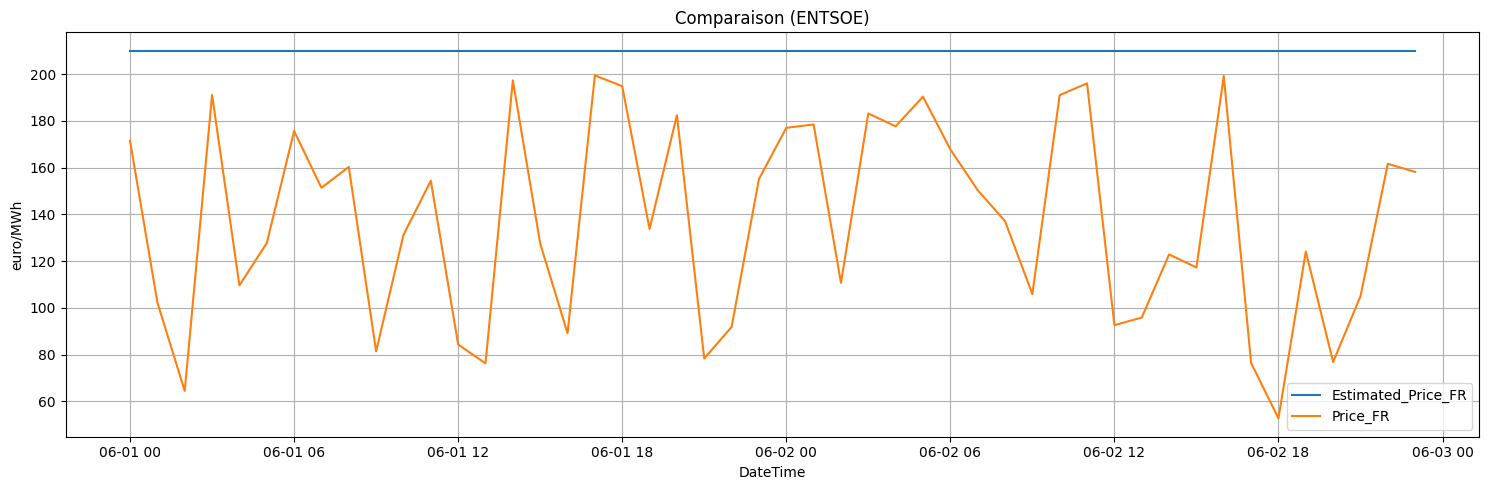

In [6]:
plot_timeseries(df, variables=['Estimated_Price_FR', 'Price_FR'], title='Comparaison', ylabel='euro/MWh')
